In [16]:
# https://www.kaggle.com/competitions/the-last-frequency

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import json
from sklearn.metrics import accuracy_score
from IPython.display import clear_output, Audio, display

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [18]:
with open('/kaggle/input/the-last-frequency/label_map.json', 'r') as f:
    idx2class = json.load(f)

idx2class = {int(k): v for k, v in idx2class.items()}

len(idx2class)

35

In [19]:
train_wav = np.load('/kaggle/input/the-last-frequency/train_waveforms.npy')
train_labels = np.load('/kaggle/input/the-last-frequency/train_labels.npy')

test1_wav = np.load('/kaggle/input/the-last-frequency/public_test_waveforms.npy')
test2_wav = np.load('/kaggle/input/the-last-frequency/private_test_waveforms.npy')

subm = pd.read_csv("/kaggle/input/the-last-frequency/sample_submission.csv")

SAMPLE_RATE = 16000

train_wav.shape, train_labels.shape, test1_wav.shape, test2_wav.shape, subm.shape

((8479, 16000), (8479,), (1060, 16000), (1060, 16000), (2120, 2))

In [20]:
print(idx2class[train_labels[3].item()])

display(Audio(data=train_wav[3], rate=SAMPLE_RATE))

three


In [21]:
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

model_id = 'facebook/wav2vec2-base'

feature_extractor = AutoFeatureExtractor.from_pretrained(model_id, sampling_rate=SAMPLE_RATE)
model = AutoModelForAudioClassification.from_pretrained(model_id, num_labels=len(idx2class))

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.weight             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
from sklearn.model_selection import train_test_split

train_wav, valid_wav, train_labels, valid_labels = train_test_split(
    train_wav, train_labels, test_size=0.1, stratify=train_labels, random_state=42
)

train_wav.shape, valid_wav.shape, train_labels.shape, valid_labels.shape

((7631, 16000), (848, 16000), (7631,), (848,))

In [23]:
class AudioDataset(Dataset):
    def __init__(self, wav, feature_extractor, labels=None):
        self.wav = wav
        self.feature_extractor = feature_extractor
        self.labels = labels
        
    def __len__(self):
        return len(self.wav)
        
    def __getitem__(self, idx):
        waveform = self.wav[idx]
        inputs = self.feature_extractor(waveform, sampling_rate=SAMPLE_RATE, return_tensors='pt')
        inputs = {k: v.squeeze() for k, v in inputs.items()}
        if self.labels is None:
            return inputs
        label = torch.tensor(self.labels[idx])
        return inputs, label

train_ds = AudioDataset(train_wav, feature_extractor, train_labels)
valid_ds = AudioDataset(valid_wav, feature_extractor, valid_labels)
test1_ds = AudioDataset(test1_wav, feature_extractor)
test2_ds = AudioDataset(test2_wav, feature_extractor)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test1_loader = DataLoader(test1_ds, batch_size=BATCH_SIZE, shuffle=False)
test2_loader = DataLoader(test2_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(valid_loader), len(test1_loader), len(test2_loader)

(239, 27, 34, 34)

In [24]:
def fit_one_epoch(model, criterion, optimizer, train_loader):
    model.train()
    i, rloss, all_y, all_preds = 0, 0, [], []
    
    for inputs, y in (pbar := tqdm(train_loader, desc='Train Loader', leave=False)):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        y = y.to(device)

        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        i += 1
        rloss += loss.item()
        all_y.extend(y.flatten().detach().cpu().tolist())
        all_preds.extend(preds.flatten().detach().cpu().tolist())
        cur_acc = accuracy_score(all_y, all_preds)
        cur_loss = rloss / i
        pbar.set_postfix({'loss': f'{cur_loss:.5f}', 'acc': f'{cur_acc:.3f}'})
        
    return cur_loss, cur_acc

def eval_one_epoch(model, criterion, valid_loader):
    model.eval()
    i, rloss, all_y, all_preds = 0, 0, [], []
    
    for inputs, y in (pbar := tqdm(valid_loader, desc='Valid Loader', leave=False)):
        inputs = {k: v.to(device) for k, v in inputs.items()}
        y = y.to(device)

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            loss = criterion(logits, y)

        i += 1
        rloss += loss.item()
        all_y.extend(y.flatten().detach().cpu().tolist())
        all_preds.extend(preds.flatten().detach().cpu().tolist())
        cur_acc = accuracy_score(all_y, all_preds)
        cur_loss = rloss / i
        pbar.set_postfix({'loss': f'{cur_loss:.5f}', 'acc': f'{cur_acc:.3f}'})
        
    return cur_loss, cur_acc

def plot_progress(history, epoch=None, epochs=None):
    clear_output(wait=True)
    
    plt.figure(figsize=(15, 7))
    if epoch is not None and epochs is not None:
        plt.title(f'Progress | Epoch {epoch+1}/{epochs}')
    else:
        plt.title('Progress')
    
    plt.subplot(1, 2, 1)
    plt.title('Losses')
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['valid_loss'], label='valid')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title('Accs')
    plt.plot(history['train_acc'], label='train')
    plt.plot(history['valid_acc'], label='valid')
    plt.legend()

    plt.tight_layout()
    plt.show()

def fit_model(model, criterion, optimizer, train_loader, valid_loader, epochs=10, history=None):
    if history is None:
        history = {
            'train_loss': [],
            'train_acc': [],
            'valid_loss': [],
            'valid_acc': []
        }

    for epoch in tqdm(range(epochs), desc='Epoch'):
        tloss, tacc = fit_one_epoch(model, criterion, optimizer, train_loader)
        vloss, vacc = eval_one_epoch(model, criterion, valid_loader)

        history['train_loss'].append(tloss)
        history['train_acc'].append(tacc)
        history['valid_loss'].append(vloss)
        history['valid_acc'].append(vacc)

        plot_progress(history, epoch, epochs)

    return history

In [25]:
flag = False

params = []

for i, module in enumerate(model.children()):
    for p in module.parameters():
        p.requires_grad = flag
        if flag:
            params.append(p)
            
    if i == 0:
        flag = True

len(params)

4

In [26]:
model = model.to(device)
optimizer = torch.optim.Adam(params, lr=2e-3)
criterion = nn.CrossEntropyLoss()

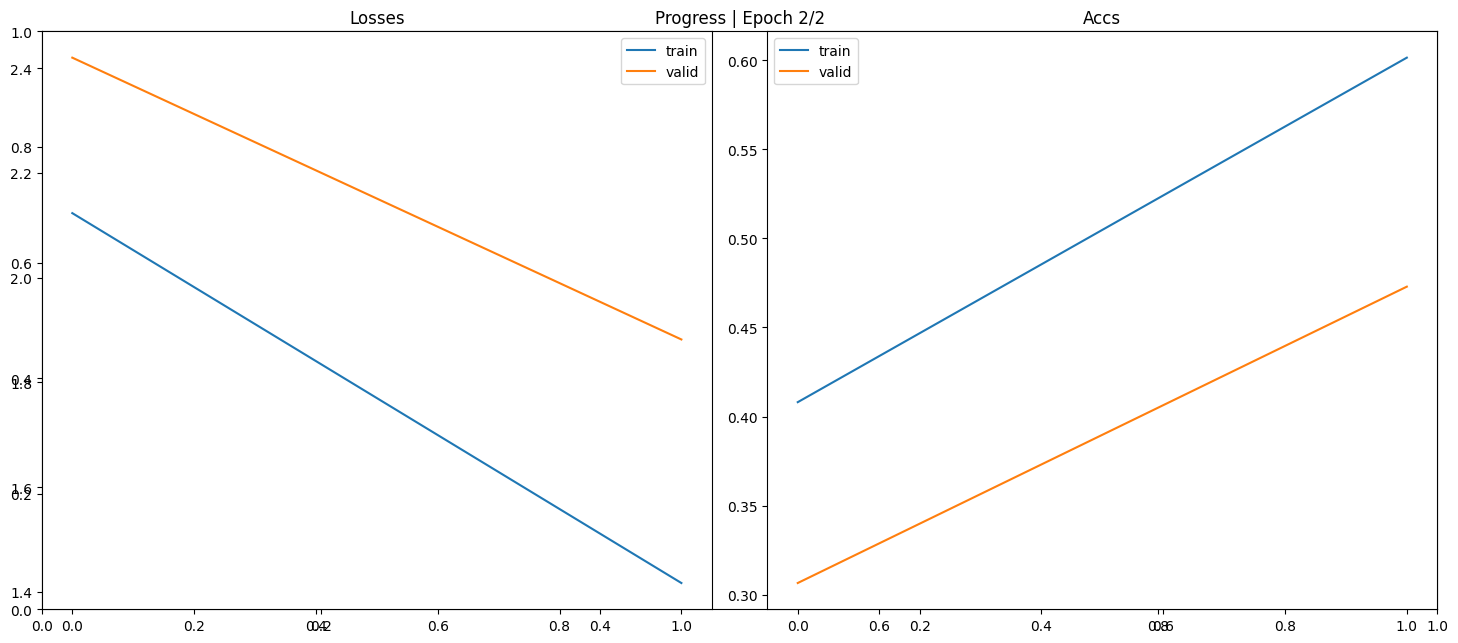

In [27]:
history = fit_model(model, criterion, optimizer, train_loader, valid_loader, epochs=2)

In [28]:
flag = False

params = []

for i, module in enumerate(model.children()):
    if i == 0:
        flag = True
        
    for p in module.parameters():
        p.requires_grad = flag
        if flag:
            params.append(p)
            
optimizer = torch.optim.Adam(params, lr=2e-5)

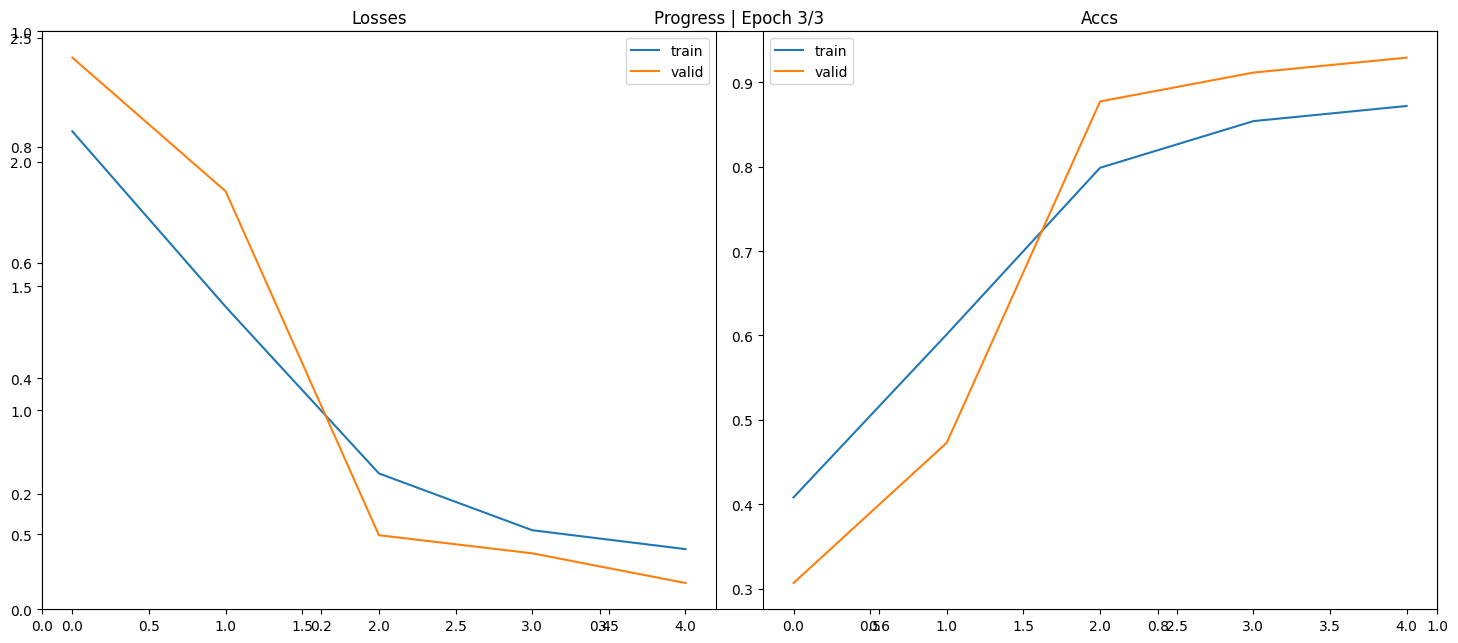

In [29]:
history = fit_model(model, criterion, optimizer, train_loader, valid_loader, epochs=3, history=history)

In [30]:
def inference(model, test_loader):
    model.eval()
    all_preds = []
    
    for inputs in tqdm(test_loader, desc='Test Loader'):
        inputs = {k: v.to(device) for k, v in inputs.items()}
    
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.flatten().detach().cpu().tolist())

    return all_preds

test1_preds = inference(model, test1_loader)
test2_preds = inference(model, test2_loader)

Test Loader:   0%|          | 0/34 [00:00<?, ?it/s]

Test Loader:   0%|          | 0/34 [00:00<?, ?it/s]

In [31]:
test1_preds = np.array(test1_preds)
test2_preds = np.array(test2_preds)

all_ids = list(range(len(test1_preds) + len(test2_preds)))
all_commands = [idx2class[p] for p in np.concatenate([test1_preds, test2_preds])]

submission = pd.DataFrame({'Id': all_ids, 'Command': all_commands})
submission.to_csv('submission.csv', index=False)

print(f'\nSaved submission.csv ({len(submission)} rows)')
print(submission.head())


Saved submission.csv (2120 rows)
   Id Command
0   0     bed
1   1    tree
2   2   happy
3   3    five
4   4    bird
